In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Gaming_Academic_Performance.csv') 

print(df.head(5)) #Simple test to see that the data loads in

   student_id  age  gender  gaming_hours  study_hours  sleep_hours  \
0           1   22    Male          7.23         8.78         6.96   
1           2   19    Male          0.07         8.72         7.63   
2           3   23  Female          1.73         9.56         4.40   
3           4   20  Female          6.62         1.68         7.83   
4           5   22  Female          5.36         5.83         5.55   

   attendance gaming_genre  social_activity  device_usage  reaction_time_ms  \
0       91.44          FPS             3.25          9.36            235.84   
1       63.63       Casual             1.02          3.21            328.71   
2       83.26       Casual             3.46          5.56            313.61   
3       75.04          RPG             1.46         11.78            241.84   
4       65.57          FPS             1.01          8.23            249.31   

   addiction_score stress_level     grades  
0            14.69          Low  86.459555  
1             

# Dataset information:

In [4]:
print(f"Dataset information: Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset information: Rows: 8000, Columns: 14


Datatypes and values:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   str    
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   str    
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   str    
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), str(3)
memory usage: 875.1 KB


Overview:

In [6]:
df.describe(include='all')

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
count,8000.00000,8000.000000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000,8000.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,FPS,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,3904,NaN,NaN,NaN,NaN,3187,NaN,NaN,NaN,NaN,4247,NaN
mean,4000.50000,19.983625,NaN,4.085773,5.460581,6.493453,79.886525,NaN,2.507790,7.586315,271.105839,9.908492,NaN,66.180776
std,2309.54541,2.587072,NaN,2.308801,2.575787,1.442656,11.580419,NaN,1.441128,2.710035,29.440675,5.035837,NaN,22.422024
min,1.00000,16.000000,NaN,0.000000,1.000000,4.000000,60.000000,NaN,0.000000,1.100000,183.260000,-4.510000,NaN,0.000000
25%,2000.75000,18.000000,NaN,2.130000,3.240000,5.240000,69.780000,NaN,1.287500,5.560000,247.160000,5.920000,NaN,49.879843
50%,4000.50000,20.000000,NaN,4.130000,5.460000,6.505000,79.695000,NaN,2.500000,7.610000,270.475000,10.005000,NaN,67.070000
75%,6000.25000,22.000000,NaN,6.060000,7.660000,7.730000,90.100000,NaN,3.760000,9.600000,294.690000,13.860000,NaN,83.992223


# Tankar om datasetet:

Efter att ha kollat på datasetet så ser jag vi har 8000 deltagare där nästan hälften är män (3904 st)
Med tanke på att vi har 3 kön borde jag förutsätta att dom andra 4096 st är kvinnor och icke binära där mindre än 3904 st är kvinnor och resten icke binära. Denna datan måste inspekteras mer för att se att datan är komplett och att mitt antagande stämmer. 

Addiction_score har ett minus värde viket är intressant med tanke på att det minsta borde vara 0. detta är något jag måste kolla närmare på.
Samma är det med Grades - Max. varför är max grade högre än 100? är det att dom kollar mot en poänglista som är högre än 100 poäng eller är det 100% som är fel? 

Jag ser att top genre är FPS. och stress_level är medium. Men eftersom att detta är top values så är frågan om FPS orsaker medelstress eller om det är andra genres som påverkar detta resultat. 



In [7]:
print("="*40)
print("Antal deltagare per kön:")
print(df['gender'].value_counts())
print("="*40)
print(f"Totalt antal: {df['gender'].count()}")

Antal deltagare per kön:
gender
Male      3904
Female    3803
Other      293
Name: count, dtype: int64
Totalt antal: 8000


Mitt antangande verkar stämma med att vi hade icke binära med i våran undersökning, och att det var mindre kvinnor än män.

In [8]:
minus_addict_score = df[df['addiction_score'] < 0]
print(f"Antal deltagare med ett negativt addiction_score: {len(minus_addict_score)}")

Antal deltagare med ett negativt addiction_score: 107


In [9]:
print(minus_addict_score[['addiction_score', 'gaming_hours', 'grades']])

      addiction_score  gaming_hours      grades
112             -0.08          0.05   81.440000
224             -1.83          0.27   86.370000
250             -1.39          1.09   71.380000
262             -1.07          0.32   58.410000
375             -1.40          0.62   70.850000
...               ...           ...         ...
7746            -0.26          1.17   86.120000
7797            -0.70          0.59  100.000000
7826            -1.67          0.95   63.160000
7875            -0.62          0.47   80.210807
7916            -0.10          0.05  100.000000

[107 rows x 3 columns]


Det verkar som att dom med ett negativt score är personer som inte har mycket spel tid.
Jag kommer att behanda dessa deltagare som att dom har 0 i spel beroende då detta skulle ge ett bättre och mer exakt slut resultat. 
Efter som att har man inget spel beroende så har man inget. 

In [10]:
over_100_grades = df[df['grades'] > 100]
print(f"Antal deltagare med över 100 i betyg:{len(over_100_grades)}")

Antal deltagare med över 100 i betyg:134


In [14]:
print(over_100_grades[['grades', 'study_hours', 'attendance']])

          grades  study_hours  attendance
22    100.815075         9.74       63.69
90    108.773228         9.41       69.30
127   109.084736         8.14       84.44
138   105.986462         9.71       82.59
205   108.899316         6.90       76.28
...          ...          ...         ...
7955  109.749279         8.51       81.41
7973  104.564137         7.91       63.87
7984  108.274369         9.81       80.58
7991  105.211520         9.14       93.97
7993  100.766366         9.36       88.32

[134 rows x 3 columns]


In [16]:
print(over_100_grades[['grades', 'study_hours', 'attendance', 'gaming_hours', 'addiction_score']])

          grades  study_hours  attendance  gaming_hours  addiction_score
22    100.815075         9.74       63.69          6.17            14.25
90    108.773228         9.41       69.30          3.47            10.78
127   109.084736         8.14       84.44          0.14             0.32
138   105.986462         9.71       82.59          0.27             1.44
205   108.899316         6.90       76.28          1.87             8.35
...          ...          ...         ...           ...              ...
7955  109.749279         8.51       81.41          0.49             2.39
7973  104.564137         7.91       63.87          0.69             3.27
7984  108.274369         9.81       80.58          3.47            10.94
7991  105.211520         9.14       93.97          1.22             5.41
7993  100.766366         9.36       88.32          5.25            14.87

[134 rows x 5 columns]


In [19]:
under_0_grades = df[df['grades'] < 0]
print(f"Antal deltagare med under 0 i betyg:{len(under_0_grades)}")

Antal deltagare med under 0 i betyg:0


Efter att ha granskat betygen så kommer jag fram till att det bara är 134 st av 8000 som har över 100 i betyg och ingen har under 0.
för att få ut en mer lättläst data borde vi göra dessa till 100. har man 100 så har man uppnåt ett högsta betyg och så spelar det ingen roll om det är 100.76 eller 100 exempelvis. 

# Tvätta data baserat på dom antaganden och upptäckter vi har gjort:

In [21]:
#Skapar en kopia av våran dataframe
df_new = df.copy()

#Fixar addiction_score så att man inte kan ha ett negativt score
df_new.loc[df_new['addiction_score'] < 0, 'addiction_score'] = 0

#Fixar grades så att vi får ett max tak på 100
df_new['grades'] = df_new['grades'].clip(upper=100.0)

print("Data tvätting gjord med dessa nya värderna:")
print(f"min addiction_score: {df_new['addiction_score'].min()}")
print(f"max grades: {df_new['grades'].max()}")
print("="*40)
print(df_new.shape[0])

Data tvätting gjord med dessa nya värderna:
min addiction_score: 0.0
max grades: 100.0
8000


In [23]:
df_new.describe(include='all')

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
count,8000.00000,8000.000000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000,8000.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,FPS,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,3904,NaN,NaN,NaN,NaN,3187,NaN,NaN,NaN,NaN,4247,NaN
mean,4000.50000,19.983625,NaN,4.085773,5.460581,6.493453,79.886525,NaN,2.507790,7.586315,271.105839,9.922191,NaN,66.080416
std,2309.54541,2.587072,NaN,2.308801,2.575787,1.442656,11.580419,NaN,1.441128,2.710035,29.440675,5.006251,NaN,22.252691
min,1.00000,16.000000,NaN,0.000000,1.000000,4.000000,60.000000,NaN,0.000000,1.100000,183.260000,0.000000,NaN,0.000000
25%,2000.75000,18.000000,NaN,2.130000,3.240000,5.240000,69.780000,NaN,1.287500,5.560000,247.160000,5.920000,NaN,49.879843
50%,4000.50000,20.000000,NaN,4.130000,5.460000,6.505000,79.695000,NaN,2.500000,7.610000,270.475000,10.005000,NaN,67.070000
75%,6000.25000,22.000000,NaN,6.060000,7.660000,7.730000,90.100000,NaN,3.760000,9.600000,294.690000,13.860000,NaN,83.992223


# Vad vill vi få ut av detta datasetet / Vad vill vi veta?

- Vem spelar vilken genre mest?
- Vilken stress nivå har dom olika genres?
- Vilken genre ger bäst betyg?
- påverkar antal spelade timmar betyget?
- påverkar spel beroende betyget?
- Om man har hög stress nivå vad påverkas mest? spelandet, sömn, eller studie tid?

# Mest Spelade genres

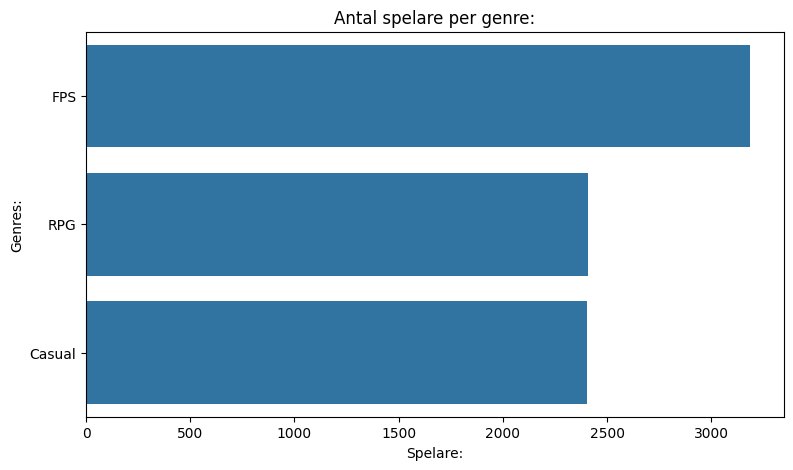

In [28]:
#hur vi ska bygga figuren
fig, ax = plt.subplots(figsize=(9,5))
#Jag använder seabord (tycker det är enklare) för att mappa ut diagramet
sns.countplot(data=df_new, y='gaming_genre', order=df_new['gaming_genre'].value_counts().index)
#namn 
ax.set_title("Antal spelare per genre:")
ax.set_ylabel("Genres:")
ax.set_xlabel("Spelare:")
#så att det vissas
plt.show()

Jag hade väl förväntat mig lite fler genres men jag antar att vi får göra så att vi får använda lite generella genres.

Jag kommer anta att:
- FPS håller alla FPS spel
- RPG håller alla RPG spel och MMO RPG spel
- Casual är alla övriga spel genres. 

Problemet med casual är att vi får anta att det håller spel som fighting spel, racing spel, och sim spel.
Detta kan påverka på hur vi kolla på stress nivån när det kommer till spel då tex ett fighting spel borde ge mer stress än vad ett sim spel borde göra. Detta är dock bara ett antagande. 

# Stress per genre

nu tänkte jag att vi skulle kolla på hur mycket stress varje spelare har baserat på vilken genre som föredrar att spela

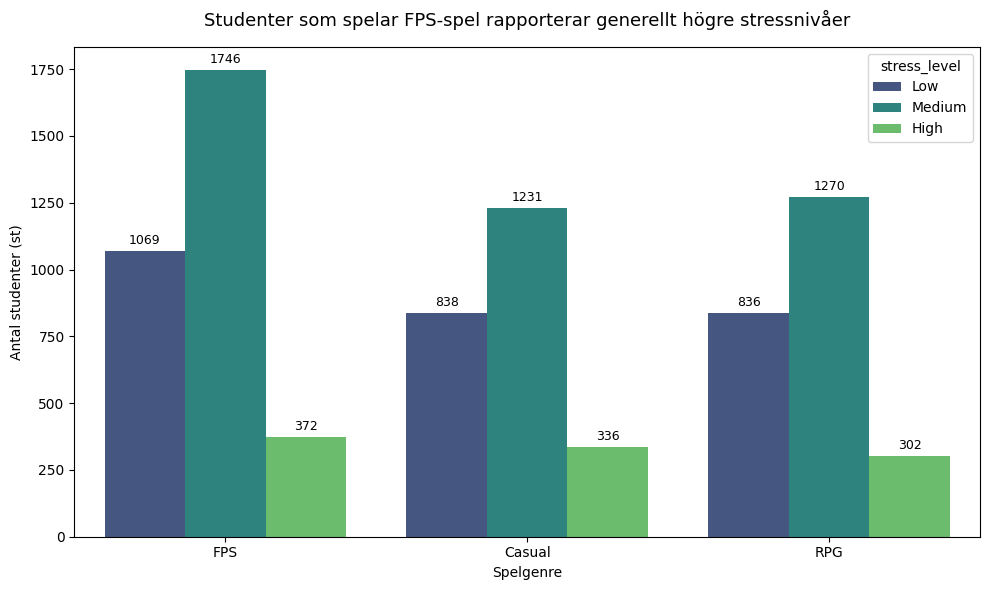

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df_new, 
    x='gaming_genre', 
    hue='stress_level', 
    hue_order=['Low', 'Medium', 'High'], #ordningen vi vill se stress nivåera
    palette='viridis', #tog bara ett pelette här
    ax=ax 
)

for container in ax.containers: #loppar igenom så att vi kan rätt i varje stapel
    ax.bar_label(container, padding=3, fontsize=9)
    
ax.set_title("Studenter som spelar FPS-spel rapporterar generellt högre stressnivåer", fontsize=13, pad=15)
ax.set_xlabel("Spelgenre")
ax.set_ylabel("Antal studenter (st)")

plt.tight_layout()
plt.show()

Nu när jag ser siffrorna framför mig så ser jag att nästa alla genres har lika många som har hög stress nivå, det som känns mer intressant är ju hur många % av spelarbasen som känner hög stress. om man bara kollar på detta så verkar Casual spelare ha högre stress än vad dom andra har. 

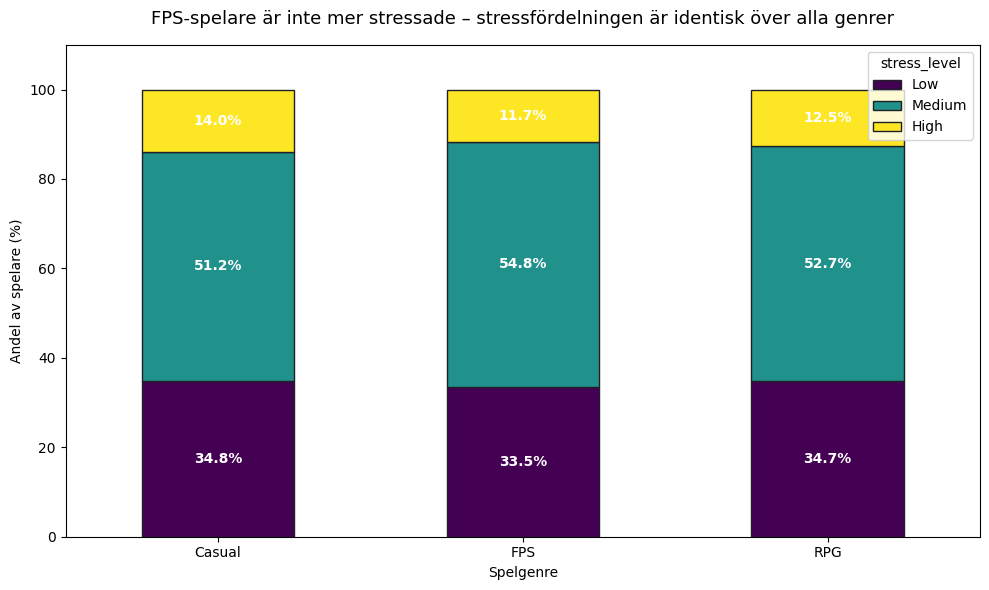

In [42]:
df_percent = pd.crosstab(df_new['gaming_genre'], df_new['stress_level'], normalize='index') * 100 #Gör varje stapel 100% av innehållet

df_percent = df_percent[['Low', 'Medium', 'High']] #delar in stress % i olika fack

fig, ax = plt.subplots(figsize=(10, 6))

#Skapa diagramet
df_percent.plot(kind='bar', stacked=True, ax=ax, color=['#440154', '#21918c', '#fde725'], edgecolor='#1f1f28')

#lägger till text inne i staplarna
for container in ax.containers:
    labels = [f'{val:.1f}%' if val > 5 else '' for val in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

ax.set_title("FPS-spelare är inte mer stressade – stressfördelningen är identisk över alla genrer", fontsize=13, pad=15)
ax.set_xlabel("Spelgenre")
ax.set_ylabel("Andel av spelare (%)")
ax.set_ylim(0, 110)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Jag känner att nu har vi fått ett mycket tydligen diagram över hur dom olika spelarnas stress nivå är över alla genres.
något som förvånar mig är att det är ganska tydligt att stressen är ungefär samma mellan dom olika genre.
Detta gör att jag egentligen hade velat ha casual ut brutet i fler sub genres. Som jag sa tidigare så kan detta vara ett ca eftersom som att dom blandar så många olika spelare och genres inom samma genre.
dom ända 2 vi kan ta som fakta är egentligen FPS och RPG eftersom som dom är mer "insolerade genres"

# Betyg vs spelade timmar

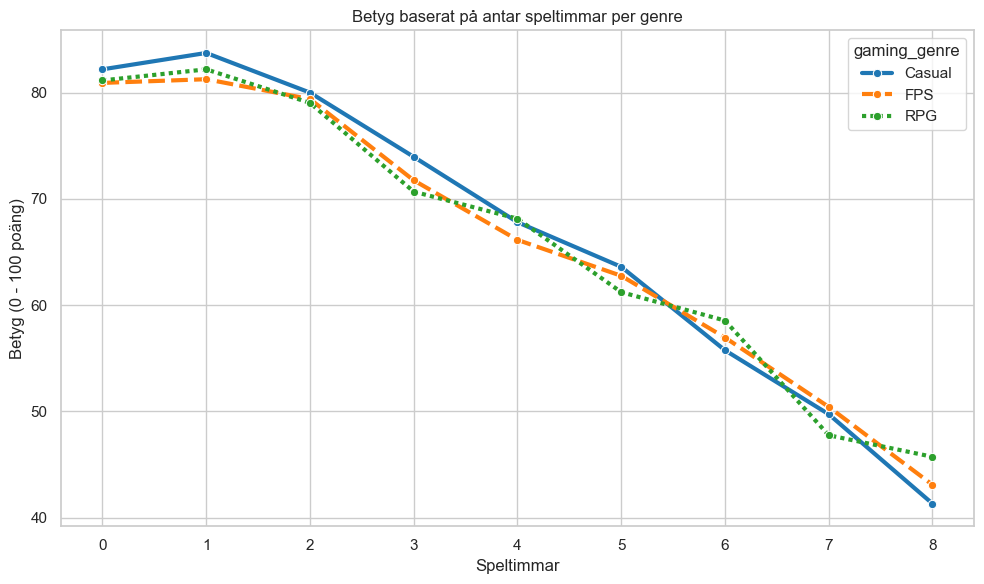

In [ ]:
#skapar en kopia för att inte råka förstöra våra rena data.
df_analysis = df_new.copy()
#fixar till så vi får hela timmar.
df_analysis['gaming_hours_rounded'] = df_analysis['gaming_hours'].round(0)

# Skapa en pivot-tabell där x = timmar och linjer = genre
pivot_data = df_analysis.pivot_table(
    index='gaming_hours_rounded', 
    columns='gaming_genre', 
    values='grades', 
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))

# Skapa linjediagram
sns.lineplot(data=pivot_data, palette="tab10", linewidth=3, ax=ax, marker="o")

# 5. VG-touch: Titel som påstående och tydliga enheter på svenska
ax.set_title("Betyg baserat på antar speltimmar per genre")
ax.set_xlabel("Speltimmar")
ax.set_ylabel("Betyg (0 - 100 poäng)")

plt.tight_layout()
plt.show()

Det som är intressant här är att vi ser att alla genre påverkar ens betyg om man spelar mer än 2 timmar om dagen.

Det är också intressant att 1 timmes speltid av casual och rpg spel kan faktiskt höja dit betyg innan det börjar gå ner för. 

Kollar man på casual så har den en snabb ner gång. från att på 1 timmes speltid höja dit betyg till 8 timmar som ger dig sämst betyg

# Betyg vs spelberoende

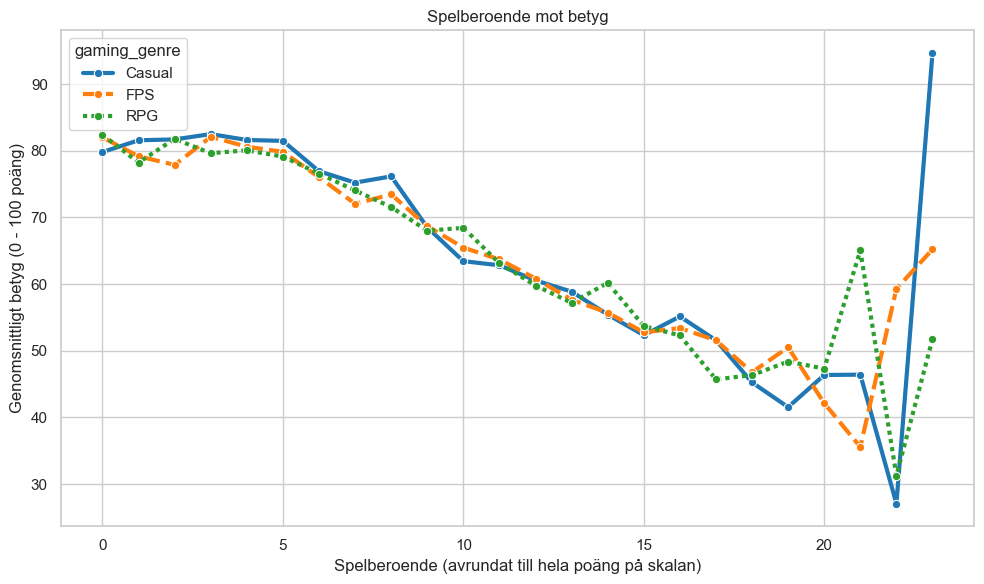

In [ ]:
#skapar en kopia för att inte råka förstöra våra rena data.
df_addiction = df_new.copy()
#rundar av addiction score till heltal
df_addiction['addiction_score_rounded'] = df_addiction['addiction_score'].round(0)

# pivot-tabell samma som ovan
pivot_addiction = df_addiction.pivot_table(
    index='addiction_score_rounded', 
    columns='gaming_genre', 
    values='grades', 
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=pivot_addiction, palette="tab10", linewidth=3, ax=ax, marker="o")

ax.set_title("Spelberoende mot betyg")
ax.set_xlabel("Spelberoende (avrundat till hela poäng på skalan)")
ax.set_ylabel("Betyg (0 - 100 poäng)")

plt.tight_layout()
plt.show()

Lite som man kan misstänka så sjuker betyget ju mer spelberoende man är fram till vi kommer till slutet av diagrammet.

Detta var något jag inte förväntade mig och det var att dom som har högst spel beroende har ett högra betyg när dom kommer över 20 så skalan.

Detta känns som något vi vill kolla nogranare på. Kan det ha att göra med att det är mindre folk som spelar och har ett hög spelberoende men ändå presterar bra? kan det ha att göra med att dom lägger mycket fokus på studier samtidigt?

# Varför hoppar betygen upp med ett hög spelberoende?

jag känner att jag måste veta varför detta händer så jag tänker att vi ska ta en koll på denna datan

mitt antagade är att det är så få personer med ett så stort spelberoende att datan blir kaos, och att dom bara råkar vara bra i skolan ändå.

men det är ändå intressant att kolla på den.

In [52]:
# 1. Filtrera fram studenter med 20 eller mer i spelberoende
df_high_addiction = df_new[df_new['addiction_score'] >= 20]

print(f"Totalt antal studenter i denna grupp: {len(df_high_addiction)} st (av 8 000)")

print("="*50)
print("hur många spelare per genre")
print(df_high_addiction['gaming_genre'].value_counts())

print("="*50)

print("Där trenden vänder:")
extreme_addict = df_new[df_new['addiction_score'] > 21.5]
print("hur många spelare per genre")
print(extreme_addict['gaming_genre'].value_counts())
print("="*50)
print("info om dom")
print(extreme_addict[['gaming_genre', 'addiction_score', 'grades']].sort_values(by='addiction_score'))

Totalt antal studenter i denna grupp: 85 st (av 8 000)
hur många spelare per genre
gaming_genre
FPS       40
RPG       23
Casual    22
Name: count, dtype: int64
Där trenden vänder:
hur många spelare per genre
gaming_genre
FPS       7
Casual    6
RPG       5
Name: count, dtype: int64
info om dom
     gaming_genre  addiction_score     grades
2692       Casual            21.58  33.180000
6898          RPG            21.58  36.880000
2760          FPS            21.62  77.833181
1507       Casual            21.76  49.900000
1075          FPS            21.78  74.128609
2184          FPS            21.79  65.875028
4746          FPS            21.82  47.570000
5552       Casual            21.91  42.390000
3687       Casual            22.00   8.300000
2892          RPG            22.05  34.820000
3708          RPG            22.07  22.070000
7579          FPS            22.15  37.030000
7352          FPS            22.30  53.368851
4459       Casual            22.42   1.510000
6105          

In [54]:
extreme_addict.describe(include='all')

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
count,18.000000,18.000000,18,18.000000,18.000000,18.000000,18.000000,18,18.000000,18.000000,18.000000,18.000000,18,18.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,FPS,NaN,NaN,NaN,NaN,Low,NaN
freq,NaN,NaN,9,NaN,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,15,NaN
mean,3834.611111,18.833333,NaN,7.628333,5.876667,6.298333,84.869444,NaN,3.198333,11.822778,226.805556,22.140556,NaN,47.127575
std,2129.310635,2.595245,NaN,0.285642,2.354682,1.523465,11.537310,NaN,1.434804,1.255879,11.685291,0.494980,NaN,24.192660
min,1076.000000,16.000000,NaN,7.000000,1.320000,4.140000,61.810000,NaN,0.590000,9.280000,206.220000,21.580000,NaN,1.510000
25%,2312.000000,17.000000,NaN,7.605000,4.542500,5.155000,79.950000,NaN,2.457500,10.995000,218.085000,21.782500,NaN,35.285000
50%,3371.500000,18.000000,NaN,7.685000,5.555000,5.930000,86.140000,NaN,3.760000,11.750000,230.170000,22.025000,NaN,44.980000
75%,5351.500000,20.750000,NaN,7.835000,7.487500,7.007500,95.567500,NaN,4.432500,12.885000,233.185000,22.390000,NaN,65.708759
